<a href="https://colab.research.google.com/github/ronald154/DocumentationPractice/blob/master/ujian_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Kecerdasan Buatan 2026
Multi Layer Perceptron untuk Klasifikasi Fashion MNIST

Nama:
NIM:

## Petunjuk

1. Setiap tugas berisi contoh yang bisa dijalankan, lalu perintah modifikasi.
2. Gunakan NIM anda sebagai seed.
3. Commit setelah setiap tugas. Minimal 5 commit.
4. Sertakan NIM di setiap output.

## Setup

Jalankan sel berikut untuk import library dan load dataset Fashion MNIST.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import random

nim = 202410370110154  # Ganti dengan NIM anda
seed = nim % (2**32)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
print(f"NIM: {nim}  Seed: {seed}")

NIM: 202410370110154  Seed: 1446351562


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

torch.manual_seed(nim)
train_subset, val_subset = random_split(train_data, [50000, 10000])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_data)}")
print(f"Kelas: {train_data.classes}")

Train: 50000, Val: 10000, Test: 10000
Kelas: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Tugas 1: Visualisasi Data (10%)

Contoh berikut menampilkan 4 gambar pertama dari dataset. Modifikasi agar menampilkan 10 gambar (satu per kelas) dalam grid 2x5 dengan judul nama kelas masing-masing.

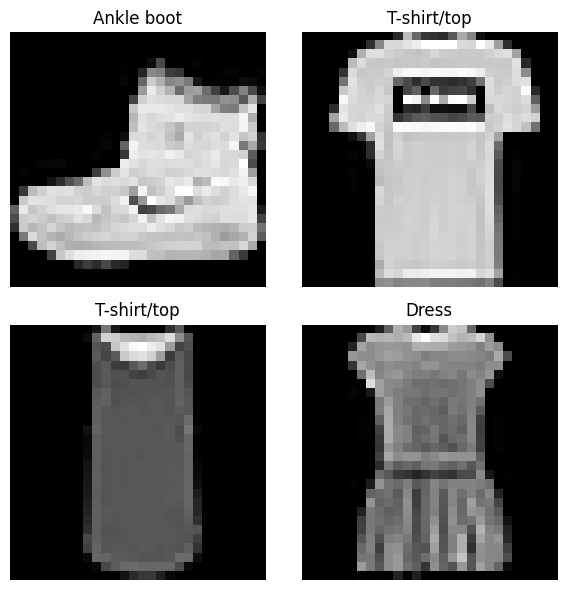

In [15]:
# Contoh: menampilkan 4 gambar dalam grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for i in range(4):
    img, label = train_data[i]
    ax = axes[i//2, i%2]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(train_data.classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

Petunjuk:
- Gunakan `plt.subplots(2, 5, figsize=(12, 6))`
- Cari index gambar pertama setiap kelas: `(train_data.targets == i).nonzero(as_tuple=True)[0][0]`
- Letakkan gambar di `axes[i//5, i%5]`

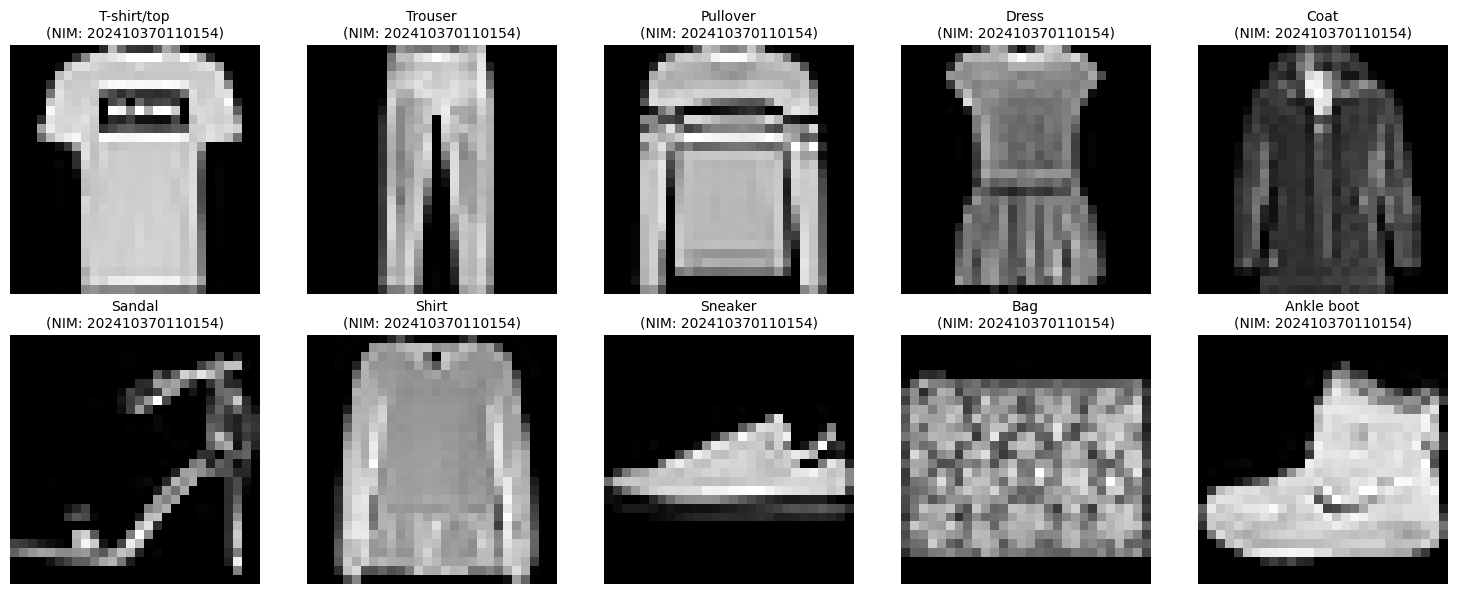

In [16]:
# Tulis kode Tugas 1 di sini (10 gambar, grid 2x5)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(10):
    # Cari index gambar pertama untuk setiap kelas
    idx = (train_data.targets == i).nonzero(as_tuple=True)[0][0].item()
    img, label = train_data[idx]

    # Tentukan posisi grid 2x5
    ax = axes[i // 5, i % 5]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"{train_data.classes[label]}\n(NIM: {nim})", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Tugas 2: Multi Layer Perceptron (25%)

Contoh berikut adalah MLP dengan 1 hidden layer (256 neuron) dan training yang hanya mencatat loss train. Modifikasi class MLP agar memiliki **2 hidden layer** (256 dan 128 neuron). Pada training, catat juga loss dan accuracy untuk data validation. Plot hasilnya dalam 2 subplot (loss dan accuracy) yang masing-masing membandingkan train vs validation.

In [17]:
# Contoh: MLP dengan 1 hidden layer
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

model = MLP()
print(model)
print(f"Parameter: {sum(p.numel() for p in model.parameters())}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)
Parameter: 203530


Epoch 1: loss = 0.5029
Epoch 2: loss = 0.3830
Epoch 3: loss = 0.3417
Epoch 4: loss = 0.3181
Epoch 5: loss = 0.2979
Epoch 6: loss = 0.2805
Epoch 7: loss = 0.2662
Epoch 8: loss = 0.2549
Epoch 9: loss = 0.2436
Epoch 10: loss = 0.2317


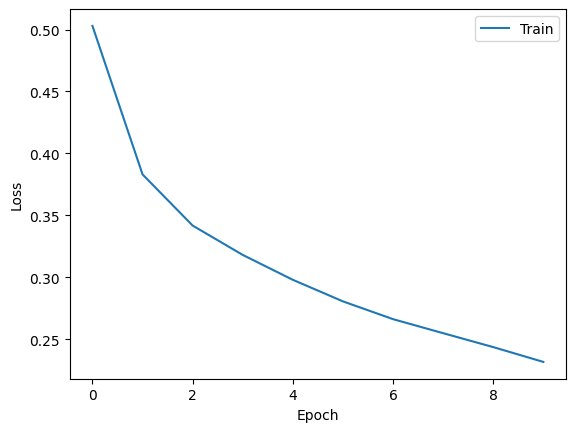

In [18]:
# Contoh: training dan plot loss (hanya train)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses = []

for epoch in range(10):
    model.train()
    running_loss = 0
    for X, y in train_loader:
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))
    print(f'Epoch {epoch+1}: loss = {train_losses[-1]:.4f}')

plt.plot(train_losses, label='Train')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Petunjuk:
- Tambah 1 hidden layer lagi di nn.Sequential: `nn.Linear(256, 128)` dan `nn.ReLU()`, lalu output `nn.Linear(128, 10)`
- Di dalam loop epoch, buat blok validation (mirip train tapi tanpa backward, gunakan `torch.no_grad()`)
- Hitung accuracy: `correct / total * 100` untuk train dan validation
- Plot dengan `plt.subplots(1, 2, figsize=(12, 4))`

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Epoch  1 | train_loss: 0.5089 val_loss: 0.4162 | train_acc: 81.64% val_acc: 84.58%
Epoch  2 | train_loss: 0.3783 val_loss: 0.3687 | train_acc: 86.04% val_acc: 86.82%
Epoch  3 | train_loss: 0.3365 val_loss: 0.3475 | train_acc: 87.61% val_acc: 87.50%
Epoch  4 | train_loss: 0.3116 val_loss: 0.3581 | train_acc: 88.43% val_acc: 87.31%
Epoch  5 | train_loss: 0.2919 val_loss: 0.3333 | train_acc: 89.28% val_acc: 87.99%
Epoch  6 | train_loss: 0.2726 val_loss: 0.3230 | train_acc: 89.70% val_acc: 88.41%
Epoch  7 | train_loss: 0.2594 val_loss: 0.3226 | train_acc: 90.30% val_acc: 88.06%
Epoch  8 | train_loss: 0.2458 val_loss: 0.3086 | train_acc: 90.93% val_acc: 89.11%
Epoch  9 | train_loss: 0.2334 val_loss: 0.3288 | train_acc: 91.21% val_acc: 88.67%
Epoc

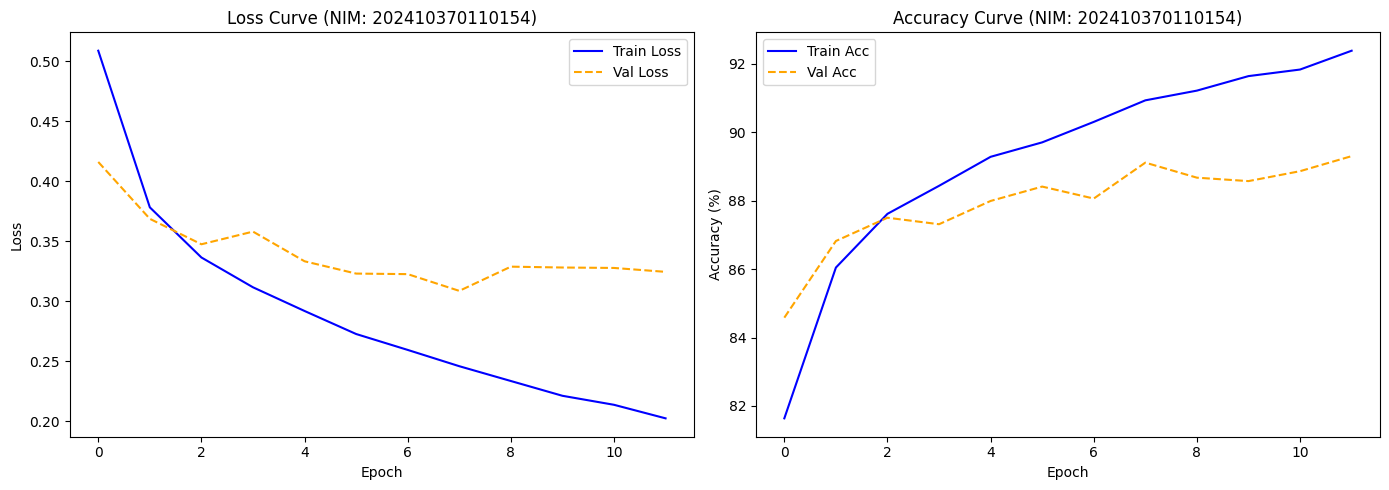

In [19]:
# Tulis ulang class MLP dengan 2 hidden layer (256 dan 128)
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

model = MLP()
print(model)

# Training dan validation
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []    # catat loss tiap epoch untuk training
val_losses = []      # catat loss tiap epoch untuk validasi
train_accs = []      # catat accuracy tiap epoch untuk training
val_accs = []        # catat accuracy tiap epoch untuk validasi

for epoch in range(12):
    # Training
    model.train()
    t_loss = 0
    t_correct = 0
    t_total = 0
    for X, y in train_loader:
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        t_loss += loss.item()
        _, pred = output.max(1)
        t_total += y.size(0)
        t_correct += pred.eq(y).sum().item()

    # Validation
    model.eval()
    v_loss = 0
    v_correct = 0
    v_total = 0
    with torch.no_grad():
        for X, y in val_loader:
            output = model(X)
            loss = criterion(output, y)

            v_loss += loss.item()
            _, pred = output.max(1)
            v_total += y.size(0)
            v_correct += pred.eq(y).sum().item()

    # Simpan hasil rata-rata
    train_losses.append(t_loss / len(train_loader))
    val_losses.append(v_loss / len(val_loader))
    train_accs.append(100.0 * t_correct / t_total)
    val_accs.append(100.0 * v_correct / v_total)
    print(f'Epoch {epoch+1:2d} | train_loss: {train_losses[-1]:.4f} val_loss: {val_losses[-1]:.4f} | train_acc: {train_accs[-1]:.2f}% val_acc: {val_accs[-1]:.2f}%')

# Plot loss dan accuracy (train vs validation) dalam 2 subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Loss
ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(val_losses, label='Val Loss', color='orange', linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title(f'Loss Curve (NIM: {nim})')
ax1.legend()

# Subplot 2: Accuracy
ax2.plot(train_accs, label='Train Acc', color='blue')
ax2.plot(val_accs, label='Val Acc', color='orange', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title(f'Accuracy Curve (NIM: {nim})')
ax2.legend()

plt.tight_layout()
plt.show()

## Tugas 3: Eksperimen Arsitektur (25%)

Contoh berikut adalah fungsi train_model dan 1 konfigurasi MLP. Buat **1 konfigurasi tambahan** (beda jumlah layer atau neuron). Bandingkan validation accuracy keduanya dalam satu plot.

In [21]:
# Contoh: fungsi training dan 1 konfigurasi MLP
def train_model(model, loader):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    accs = []
    for epoch in range(8):
        model.train()
        correct = total = 0
        for X, y in loader:
            optimizer.zero_grad()
            output = model(X)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            _, pred = output.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()
        accs.append(100.0 * correct / total)
    return accs

class MLP1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

model_a = MLP1()
acc_a = train_model(model_a, train_loader)
print(f"MLP 1 layer (128): akurasi = {acc_a[-1]:.2f}%")

MLP 1 layer (128): akurasi = 90.17%


Petunjuk:
- Buat class MLP2 dengan arsitektur berbeda
- Gunakan train_model() untuk melatih
- Plot accuracy kedua model dalam satu grafik

MLP2(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)
Parameter MLP2: 567434
Akurasi MLP2: 90.76%


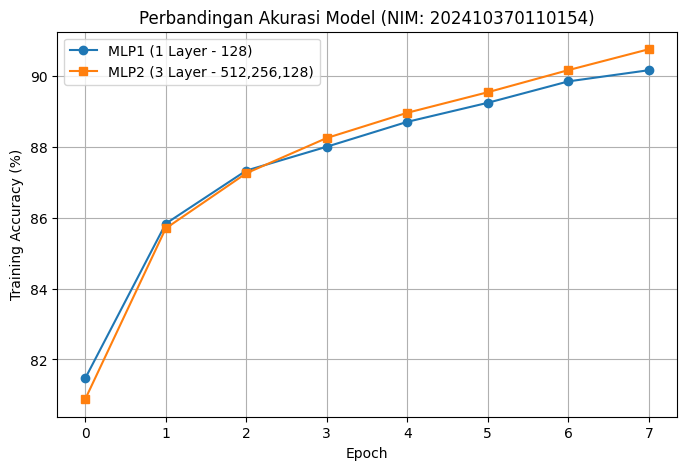

In [22]:
# Tulis kode eksperimen di sini: 1 konfigurasi tambahan

# Class MLP2 dengan 3 hidden layer (kapasitas lebih besar)
class MLP2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

model_b = MLP2()
print(model_b)
print(f"Parameter MLP2: {sum(p.numel() for p in model_b.parameters())}")

# Latih model_b menggunakan train_model() yang sudah disediakan di atasnya
acc_b = train_model(model_b, train_loader)
print(f"Akurasi MLP2: {acc_b[-1]:.2f}%")

# Plot perbandingan akurasi acc_a (MLP1) dan acc_b (MLP2) dalam satu grafik
plt.figure(figsize=(8, 5))
plt.plot(acc_a, label='MLP1 (1 Layer - 128)', marker='o')
plt.plot(acc_b, label='MLP2 (3 Layer - 512,256,128)', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.title(f'Perbandingan Akurasi Model (NIM: {nim})')
plt.legend()
plt.grid(True)
plt.show()

## Tugas 4: Evaluasi Model (20%)

Pilih model terbaik dari Tugas 3. Contoh berikut menghitung accuracy pada data test. Lengkapi dengan confusion matrix (heatmap) dan classification report (precision, recall, F1-score per kelas).

In [23]:
# Contoh: evaluasi accuracy (gunakan model sederhana sebagai demo)
class ContohModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 10))
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

contoh_model = ContohModel()
contoh_model.eval()
correct = total = 0
with torch.no_grad():
    for X, y in test_loader:
        output = contoh_model(X)
        _, pred = output.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()

print(f"Test accuracy (contoh): {100.0 * correct / total:.2f}%")

Test accuracy (contoh): 12.66%


Petunjuk:
- Gunakan `confusion_matrix(all_labels, all_preds)` dari sklearn
- Tampilkan dengan `sns.heatmap(..., annot=True, fmt='d')`
- Gunakan `classification_report(..., target_names=train_data.classes)`

Test accuracy: 88.20%


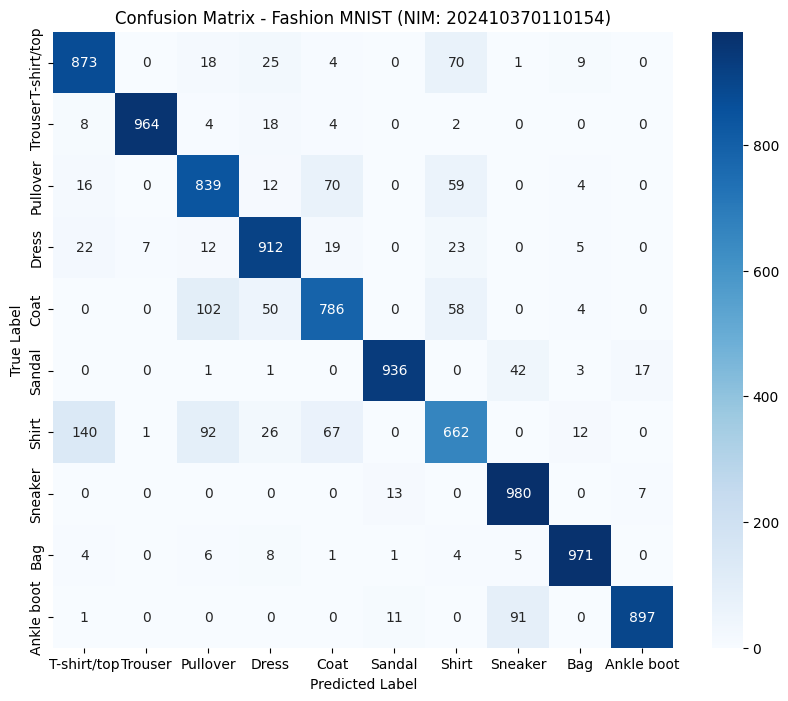


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.87      0.85      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.78      0.84      0.81      1000
       Dress       0.87      0.91      0.89      1000
        Coat       0.83      0.79      0.81      1000
      Sandal       0.97      0.94      0.95      1000
       Shirt       0.75      0.66      0.71      1000
     Sneaker       0.88      0.98      0.92      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.97      0.90      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [25]:
# Tulis ulang kode evaluasi di sini (accuracy + confusion matrix + classification report)

# Memilih model terbaik dari Tugas 3
best_model = model_b

best_model.eval()
all_preds = []
all_labels = []
correct = 0
total = 0

with torch.no_grad():
    for X, y in test_loader:
        output = best_model(X)
        _, pred = output.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()

        # Mengumpulkan semua prediksi dan label asli
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

accuracy = 100.0 * correct / total
print(f"Test accuracy: {accuracy:.2f}%")

# Hitung confusion matrix menggunakan scikit-learn
cm = confusion_matrix(all_labels, all_preds)

# Tampilkan heatmap matriks konfusi menggunakan seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_data.classes,
            yticklabels=train_data.classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix - Fashion MNIST (NIM: {nim})')
plt.show()

# Menampilkan laporan klasifikasi terperinci
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_data.classes))

In [26]:
# Verifikasi
print(f"NIM: {nim}")
print(f"Test accuracy: {accuracy:.2f}%")
print(f"Parameter model: {sum(p.numel() for p in best_model.parameters())}")

NIM: 202410370110154
Test accuracy: 88.20%
Parameter model: 567434


## Tugas 5: Analisis (20%)

Jawab pertanyaan berikut pada sel di bawah. Jawaban harus spesifik merujuk pada output yang anda peroleh.

1. Lihat grafik loss Tugas 2. Pada epoch berapa validation loss mulai naik atau berhenti turun? Apa artinya?

2. Bandingkan accuracy kedua model di Tugas 3. Model mana yang lebih baik? Mengapa jumlah layer/neuron mempengaruhi hasil?

3. Dari confusion matrix Tugas 4, sebutkan 2 kelas yang paling sering salah prediksi dan berapa jumlahnya. Jelaskan kemiripan visualnya.

4. NIM digunakan sebagai seed. Bagian mana dari eksperimen yang terpengaruh seed? Apakah hasil anda akan berbeda dengan mahasiswa lain? Jelaskan.

### Jawaban Analisis

1.


2.


3.


4.